# Singular Value Decomposition (SVD)

Section 7.5 introduces the **SVD**, the most important matrix decomposition in applied mathematics. Any real $m \times n$ matrix $\mathbf{A}$ can be written as

$$\mathbf{A} = \mathbf{U} \mathbf{S} \mathbf{V}^T = \sum_{i=1}^{r} \sigma_i \, \mathbf{u}_i \mathbf{v}_i^T$$

where:
- $\mathbf{U}$ ($m \times m$) has orthonormal columns — the **left singular vectors**
- $\mathbf{V}$ ($n \times n$) has orthonormal columns — the **right singular vectors**
- $\mathbf{S}$ ($m \times n$) is diagonal with **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$

We'll work through every subsection of 7.5 — basics, connection to EVD, pseudo inverse, range/null space, and truncated SVD — using a single running example.

### Real-World Scenario: Gene Expression Profiling

In genomics, a gene expression matrix $\mathbf{A}$ has **samples as rows** and **genes as columns**. Each entry measures how actively a gene is transcribed in a given tissue sample. SVD reveals the hidden **biological programs** (cell type signatures, pathway activations) that explain most of the variation across samples — this is the foundation of methods like PCA in bioinformatics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. Building the Gene Expression Matrix

We simulate a $10 \times 6$ gene expression matrix (10 tissue samples, 6 genes) driven by **3 latent biological programs**:

| Program | Biological meaning | Genes affected |
|:---:|:---:|:---:|
| Program 1 | Immune response | Genes 1, 2 (strongly), Gene 3 (weakly) |
| Program 2 | Cell proliferation | Genes 3, 4 |
| Program 3 | Metabolic activity | Genes 5, 6 |

The matrix thus has **true rank 3** (plus some noise), so only 3 singular values should be dominant.

In [2]:
m, n = 10, 6  # 10 samples, 6 genes
r_true = 3     # 3 latent biological programs

# Sample activations: how much each program is active in each sample
# Shape: (m, r_true)
activations = np.array([
    [3.0, 0.5, 1.0],  # sample 0: strong immune, low prolif, moderate metabolic
    [2.8, 0.3, 1.2],  # sample 1: similar to 0
    [0.2, 3.5, 0.8],  # sample 2: strong proliferation (tumor-like)
    [0.1, 3.8, 0.5],  # sample 3: similar to 2
    [0.3, 3.2, 0.9],  # sample 4: similar to 2, 3
    [1.5, 1.5, 2.5],  # sample 5: mixed, high metabolic
    [1.2, 1.8, 2.8],  # sample 6: similar to 5
    [2.5, 0.2, 0.3],  # sample 7: strong immune only
    [0.5, 0.3, 3.5],  # sample 8: strong metabolic
    [0.4, 0.2, 3.2],  # sample 9: similar to 8
])

# Gene loadings: how each program affects each gene
# Shape: (r_true, n)
loadings = np.array([
    [4.0, 3.5, 0.5, 0.0, 0.0, 0.0],  # program 1 → genes 1-2 (immune)
    [0.0, 0.0, 2.0, 3.0, 0.0, 0.0],  # program 2 → genes 3-4 (proliferation)
    [0.0, 0.0, 0.0, 0.0, 2.5, 2.0],  # program 3 → genes 5-6 (metabolic)
])

# Clean signal: rank-3 matrix
A_clean = activations @ loadings

# Add small noise (measurement error)
noise = 0.3 * np.random.randn(m, n)
A = A_clean + noise

gene_names = ['IL6', 'TNFα', 'MKI67', 'PCNA', 'GLUT1', 'LDHA']
sample_names = [f'S{i}' for i in range(m)]

print(f"Gene expression matrix A: {A.shape[0]} samples × {A.shape[1]} genes")
print(f"True rank of signal: {r_true}")
print(f"\nA (rounded):")
print(f"{'':>4}", '  '.join(f'{g:>6}' for g in gene_names))
for i in range(m):
    print(f'{sample_names[i]:>4}', '  '.join(f'{A[i,j]:6.2f}' for j in range(n)))

Gene expression matrix A: 10 samples × 6 genes
True rank of signal: 3

A (rounded):
        IL6    TNFα   MKI67    PCNA   GLUT1    LDHA
  S0  12.15   10.46    2.69    1.96    2.43    1.93
  S1  11.67   10.03    1.86    1.06    2.86    2.26
  S2   0.87    0.13    6.58   10.33    1.70    1.69
  S3   0.13   -0.07    8.09   11.33    1.27    0.57
  S4   1.04    1.08    6.20    9.71    2.07    1.71
  S5   5.82    5.81    3.75    4.18    6.50    4.63
  S6   4.86    3.61    3.80    5.46    7.22    5.65
  S7   9.97    8.66    1.21    0.38    0.61    0.92
  S8   2.10    1.22    0.95    0.78    8.55    7.18
  S9   1.91    1.68    0.35    0.51    8.10    6.69


---
## 2. Computing the SVD (Section 7.5.1)

The full SVD factorizes $\mathbf{A} = \mathbf{U} \mathbf{S} \mathbf{V}^T$ where:
- $\mathbf{U}$ is $m \times m$ (orthogonal)
- $\mathbf{S}$ is $m \times n$ (diagonal with singular values)
- $\mathbf{V}$ is $n \times n$ (orthogonal)

The **economy (thin) SVD** only keeps the first $\min(m,n)$ columns of $\mathbf{U}$ and the corresponding rows of $\mathbf{S}$, since the rest multiply by zeros anyway.

NumPy's `np.linalg.svd` returns the economy SVD by default when `full_matrices=False`.

In [3]:
# Full SVD
U_full, sigma_full, Vt_full = np.linalg.svd(A, full_matrices=True)
print("Full SVD shapes:")
print(f"  U:  {U_full.shape}  (m × m)")
print(f"  σ:  {sigma_full.shape}  (min(m,n) singular values)")
print(f"  Vᵀ: {Vt_full.shape}  (n × n)")

# Economy (thin) SVD
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
print(f"\nEconomy SVD shapes:")
print(f"  U:  {U.shape}  (m × min(m,n))")
print(f"  σ:  {sigma.shape}  (min(m,n) singular values)")
print(f"  Vᵀ: {Vt.shape}  (min(m,n) × n)")

print(f"\nSingular values: {sigma.round(2)}")
print(f"\nVerify reconstruction A ≈ U S Vᵀ: {np.allclose(A, U @ np.diag(sigma) @ Vt)}")

Full SVD shapes:
  U:  (10, 10)  (m × m)
  σ:  (6,)  (min(m,n) singular values)
  Vᵀ: (6, 6)  (n × n)

Economy SVD shapes:
  U:  (10, 6)  (m × min(m,n))
  σ:  (6,)  (min(m,n) singular values)
  Vᵀ: (6, 6)  (min(m,n) × n)

Singular values: [33.41 21.1  14.77  1.16  0.73  0.43]

Verify reconstruction A ≈ U S Vᵀ: True


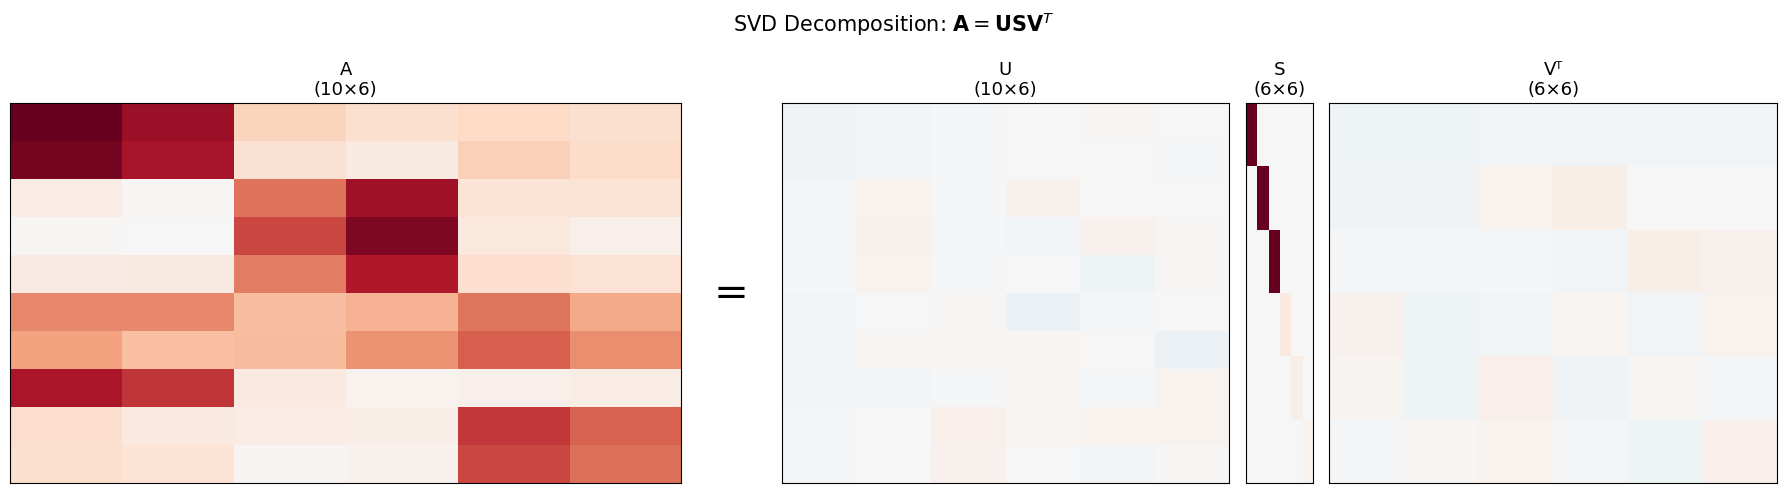

In [4]:
# Visualize the SVD decomposition
S_mat = np.diag(sigma)

fig, axes = plt.subplots(1, 5, figsize=(18, 5),
                         gridspec_kw={'width_ratios': [3, 0.3, 2, 0.3, 2]})

matrices = [A, None, U, S_mat, Vt]
titles = [f'A\n({m}×{n})', '=', f'U\n({m}×{n})', f'S\n({n}×{n})', f'Vᵀ\n({n}×{n})']

for ax, mat, title in zip(axes, matrices, titles):
    if mat is None:
        ax.text(0.5, 0.5, '=', fontsize=30, ha='center', va='center',
                transform=ax.transAxes)
        ax.axis('off')
        continue
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto',
                   vmin=-np.max(np.abs(A)), vmax=np.max(np.abs(A)))
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('SVD Decomposition: $\mathbf{A} = \mathbf{U} \mathbf{S} \mathbf{V}^T$', fontsize=15)
plt.tight_layout()
plt.show()

---
## 3. Outer Product Form: $A = \sum \sigma_i \mathbf{u}_i \mathbf{v}_i^T$

From Eq. 7.178, the SVD can be written as a **sum of rank-1 matrices**:

$$\mathbf{A} = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^T + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^T + \cdots + \sigma_r \mathbf{u}_r \mathbf{v}_r^T$$

Each term $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$ is a rank-1 "layer" weighted by $\sigma_i$. In our gene expression context, each layer corresponds to a **biological program**: $\mathbf{u}_i$ tells us which samples are affected and $\mathbf{v}_i$ tells us which genes are involved.

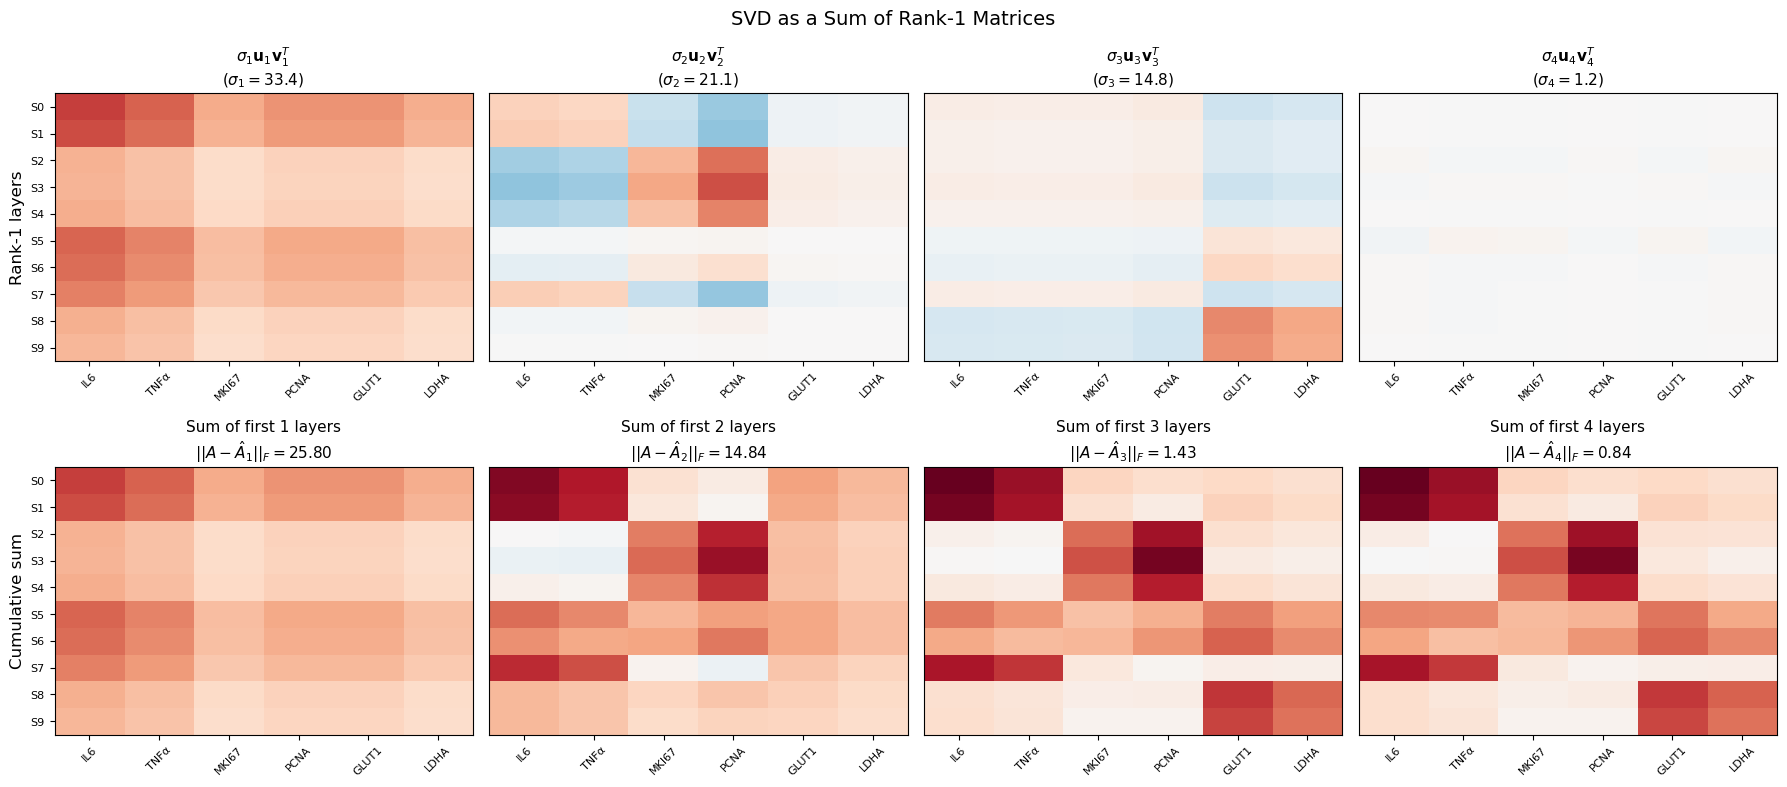

Each layer captures one biological program.
The first 3 layers capture most of the signal (since true rank = 3).
Layers 4+ capture mostly noise.


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
vmax = np.max(np.abs(A))

cumulative = np.zeros_like(A)
for k in range(min(n, 4)):
    # Rank-1 component
    layer = sigma[k] * np.outer(U[:, k], Vt[k, :])
    cumulative += layer
    
    # Top row: individual rank-1 layers
    ax = axes[0, k]
    ax.imshow(layer, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(f'$\\sigma_{k+1} \\mathbf{{u}}_{k+1} \\mathbf{{v}}_{k+1}^T$\n($\\sigma_{k+1}={sigma[k]:.1f}$)',
                fontsize=11)
    if k == 0:
        ax.set_yticks(range(m))
        ax.set_yticklabels(sample_names, fontsize=8)
    else:
        ax.set_yticks([])
    ax.set_xticks(range(n))
    ax.set_xticklabels(gene_names, rotation=45, fontsize=8)
    
    # Bottom row: cumulative reconstruction
    ax = axes[1, k]
    ax.imshow(cumulative, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    error = np.linalg.norm(A - cumulative, 'fro')
    ax.set_title(f'Sum of first {k+1} layers\n$||A - \\hat{{A}}_{k+1}||_F = {error:.2f}$',
                fontsize=11)
    if k == 0:
        ax.set_yticks(range(m))
        ax.set_yticklabels(sample_names, fontsize=8)
    else:
        ax.set_yticks([])
    ax.set_xticks(range(n))
    ax.set_xticklabels(gene_names, rotation=45, fontsize=8)

axes[0, 0].set_ylabel('Rank-1 layers', fontsize=12)
axes[1, 0].set_ylabel('Cumulative sum', fontsize=12)
plt.suptitle('SVD as a Sum of Rank-1 Matrices', fontsize=14)
plt.tight_layout()
plt.show()

print("Each layer captures one biological program.")
print("The first 3 layers capture most of the signal (since true rank = 3).")
print("Layers 4+ capture mostly noise.")

---
## 4. Properties of U, S, V

Let's verify the key properties from Section 7.5.1:
- $\mathbf{U}^T \mathbf{U} = \mathbf{I}$ (columns of $\mathbf{U}$ are orthonormal)
- $\mathbf{V}^T \mathbf{V} = \mathbf{V} \mathbf{V}^T = \mathbf{I}$ (V is square orthogonal)
- Singular values are non-negative and sorted in decreasing order

In [6]:
V = Vt.T  # V is the transpose of Vt

print("Property checks:")
print(f"  UᵀU ≈ I (orthonormal columns): {np.allclose(U.T @ U, np.eye(n))}")
print(f"  VᵀV ≈ I: {np.allclose(V.T @ V, np.eye(n))}")
print(f"  VVᵀ ≈ I: {np.allclose(V @ V.T, np.eye(n))}")
print(f"  Singular values non-negative: {np.all(sigma >= 0)}")
print(f"  Singular values sorted: {np.all(np.diff(sigma) <= 0)}")

print(f"\nUᵀU (should be identity):")
print((U.T @ U).round(6))

print(f"\nSingular values: {sigma.round(3)}")
print(f"\nNote: σ₁={sigma[0]:.1f}, σ₂={sigma[1]:.1f}, σ₃={sigma[2]:.1f} are large (signal)")
print(f"      σ₄={sigma[3]:.2f}, σ₅={sigma[4]:.2f}, σ₆={sigma[5]:.2f} are small (noise)")

Property checks:
  UᵀU ≈ I (orthonormal columns): True
  VᵀV ≈ I: True
  VVᵀ ≈ I: True
  Singular values non-negative: True
  Singular values sorted: True

UᵀU (should be identity):
[[ 1. -0. -0.  0. -0. -0.]
 [-0.  1.  0. -0.  0.  0.]
 [-0.  0.  1.  0. -0.  0.]
 [ 0. -0.  0.  1.  0. -0.]
 [-0.  0. -0.  0.  1.  0.]
 [-0.  0.  0. -0.  0.  1.]]

Singular values: [33.405 21.101 14.773  1.159  0.729  0.426]

Note: σ₁=33.4, σ₂=21.1, σ₃=14.8 are large (signal)
      σ₄=1.16, σ₅=0.73, σ₆=0.43 are small (noise)


---
## 5. Connection Between SVD and EVD (Section 7.5.2)

The SVD is intimately connected to eigendecompositions:

$$\mathbf{A}^T \mathbf{A} = \mathbf{V} (\mathbf{S}^T \mathbf{S}) \mathbf{V}^T \qquad \Rightarrow \qquad \text{eigenvectors of } \mathbf{A}^T\mathbf{A} = \mathbf{V}, \quad \text{eigenvalues} = \sigma_i^2$$

$$\mathbf{A} \mathbf{A}^T = \mathbf{U} (\mathbf{S} \mathbf{S}^T) \mathbf{U}^T \qquad \Rightarrow \qquad \text{eigenvectors of } \mathbf{A}\mathbf{A}^T = \mathbf{U}, \quad \text{eigenvalues} = \sigma_i^2$$

In genomics:
- $\mathbf{A}^T \mathbf{A}$ is proportional to the **gene-gene covariance** (which genes co-vary across samples)
- $\mathbf{A} \mathbf{A}^T$ is proportional to the **sample-sample covariance** (which samples have similar profiles)

In [7]:
# AᵀA: gene-gene covariance structure
AtA = A.T @ A
evals_AtA, evecs_AtA = np.linalg.eigh(AtA)

# Sort eigenvalues in decreasing order (eigh returns ascending)
idx = np.argsort(evals_AtA)[::-1]
evals_AtA = evals_AtA[idx]
evecs_AtA = evecs_AtA[:, idx]

# AAᵀ: sample-sample covariance structure
AAt = A @ A.T
evals_AAt, evecs_AAt = np.linalg.eigh(AAt)
idx2 = np.argsort(evals_AAt)[::-1]
evals_AAt = evals_AAt[idx2]
evecs_AAt = evecs_AAt[:, idx2]

print("Eigenvalues of AᵀA vs. squared singular values:")
print(f"  eig(AᵀA):  {evals_AtA[:n].round(3)}")
print(f"  σ²:        {(sigma**2).round(3)}")
print(f"  Match: {np.allclose(evals_AtA[:n], sigma**2)}")

print(f"\nEigenvalues of AAᵀ (first {n} non-zero) vs. squared singular values:")
print(f"  eig(AAᵀ):  {evals_AAt[:n].round(3)}")
print(f"  σ²:        {(sigma**2).round(3)}")
print(f"  Match: {np.allclose(evals_AAt[:n], sigma**2)}")

# Note: eigenvectors may differ by sign (both ±u are valid eigenvectors)
# Check that they span the same space by comparing |correlation|
print(f"\nRight singular vectors V vs. eigenvectors of AᵀA:")
correlation = np.abs(np.diag(Vt @ evecs_AtA))
print(f"  |correlation| per vector: {correlation.round(4)}")
print(f"  (1.0 = same direction, up to sign)")

Eigenvalues of AᵀA vs. squared singular values:
  eig(AᵀA):  [1.115895e+03 4.452340e+02 2.182330e+02 1.343000e+00 5.320000e-01
 1.810000e-01]
  σ²:        [1.115895e+03 4.452340e+02 2.182330e+02 1.343000e+00 5.320000e-01
 1.810000e-01]
  Match: True

Eigenvalues of AAᵀ (first 6 non-zero) vs. squared singular values:
  eig(AAᵀ):  [1.115895e+03 4.452340e+02 2.182330e+02 1.343000e+00 5.320000e-01
 1.810000e-01]
  σ²:        [1.115895e+03 4.452340e+02 2.182330e+02 1.343000e+00 5.320000e-01
 1.810000e-01]
  Match: True

Right singular vectors V vs. eigenvectors of AᵀA:
  |correlation| per vector: [1. 1. 1. 1. 1. 1.]
  (1.0 = same direction, up to sign)


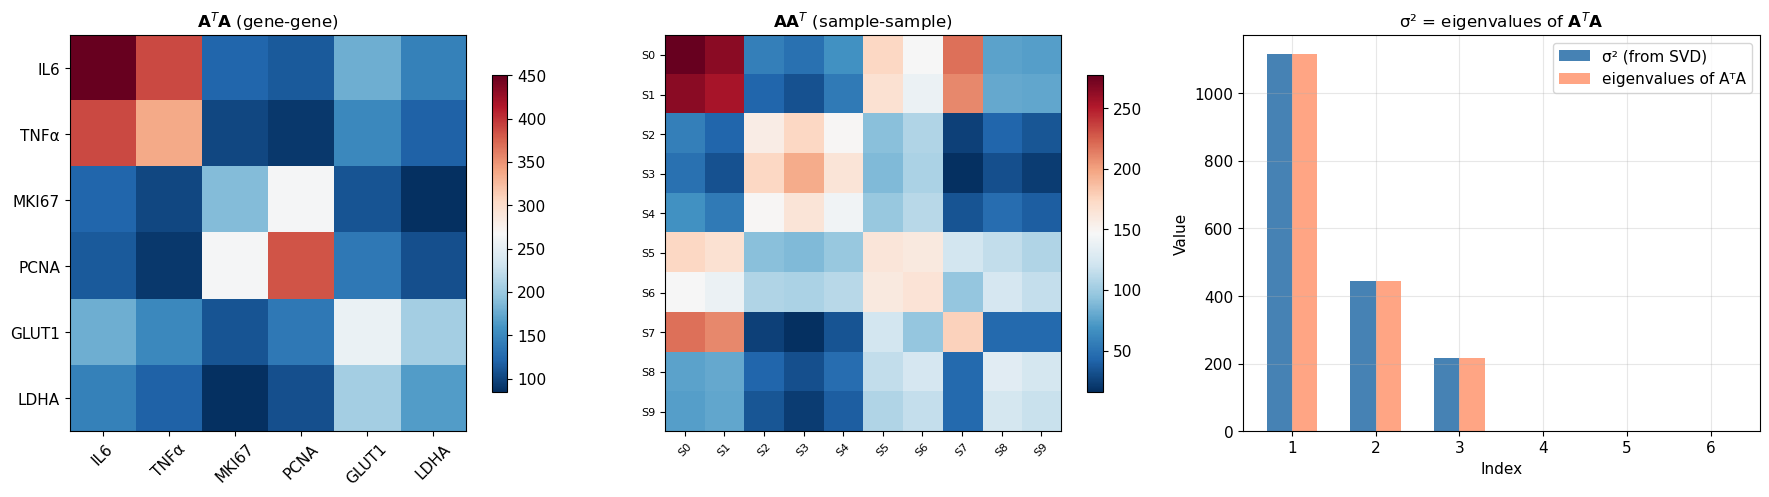

In [8]:
# Visualize the gene-gene and sample-sample covariance matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gene-gene covariance
ax = axes[0]
im = ax.imshow(AtA, cmap='RdBu_r', aspect='equal')
ax.set_xticks(range(n))
ax.set_xticklabels(gene_names, rotation=45)
ax.set_yticks(range(n))
ax.set_yticklabels(gene_names)
ax.set_title('$\mathbf{A}^T\mathbf{A}$ (gene-gene)', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)

# Sample-sample covariance
ax = axes[1]
im = ax.imshow(AAt, cmap='RdBu_r', aspect='equal')
ax.set_xticks(range(m))
ax.set_xticklabels(sample_names, rotation=45, fontsize=8)
ax.set_yticks(range(m))
ax.set_yticklabels(sample_names, fontsize=8)
ax.set_title('$\mathbf{A}\mathbf{A}^T$ (sample-sample)', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)

# Singular values vs. eigenvalues
ax = axes[2]
x_pos = np.arange(n)
ax.bar(x_pos - 0.15, sigma**2, width=0.3, label='σ² (from SVD)', color='steelblue')
ax.bar(x_pos + 0.15, evals_AtA, width=0.3, label='eigenvalues of AᵀA', color='coral', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{i+1}' for i in range(n)])
ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.set_title('σ² = eigenvalues of $\mathbf{A}^T\mathbf{A}$', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Interpreting Singular Vectors

The **right singular vectors** $\mathbf{v}_i$ (columns of $\mathbf{V}$) tell us the **gene patterns** — which genes participate in each biological program.

The **left singular vectors** $\mathbf{u}_i$ (columns of $\mathbf{U}$) tell us the **sample patterns** — which samples are active for each program.

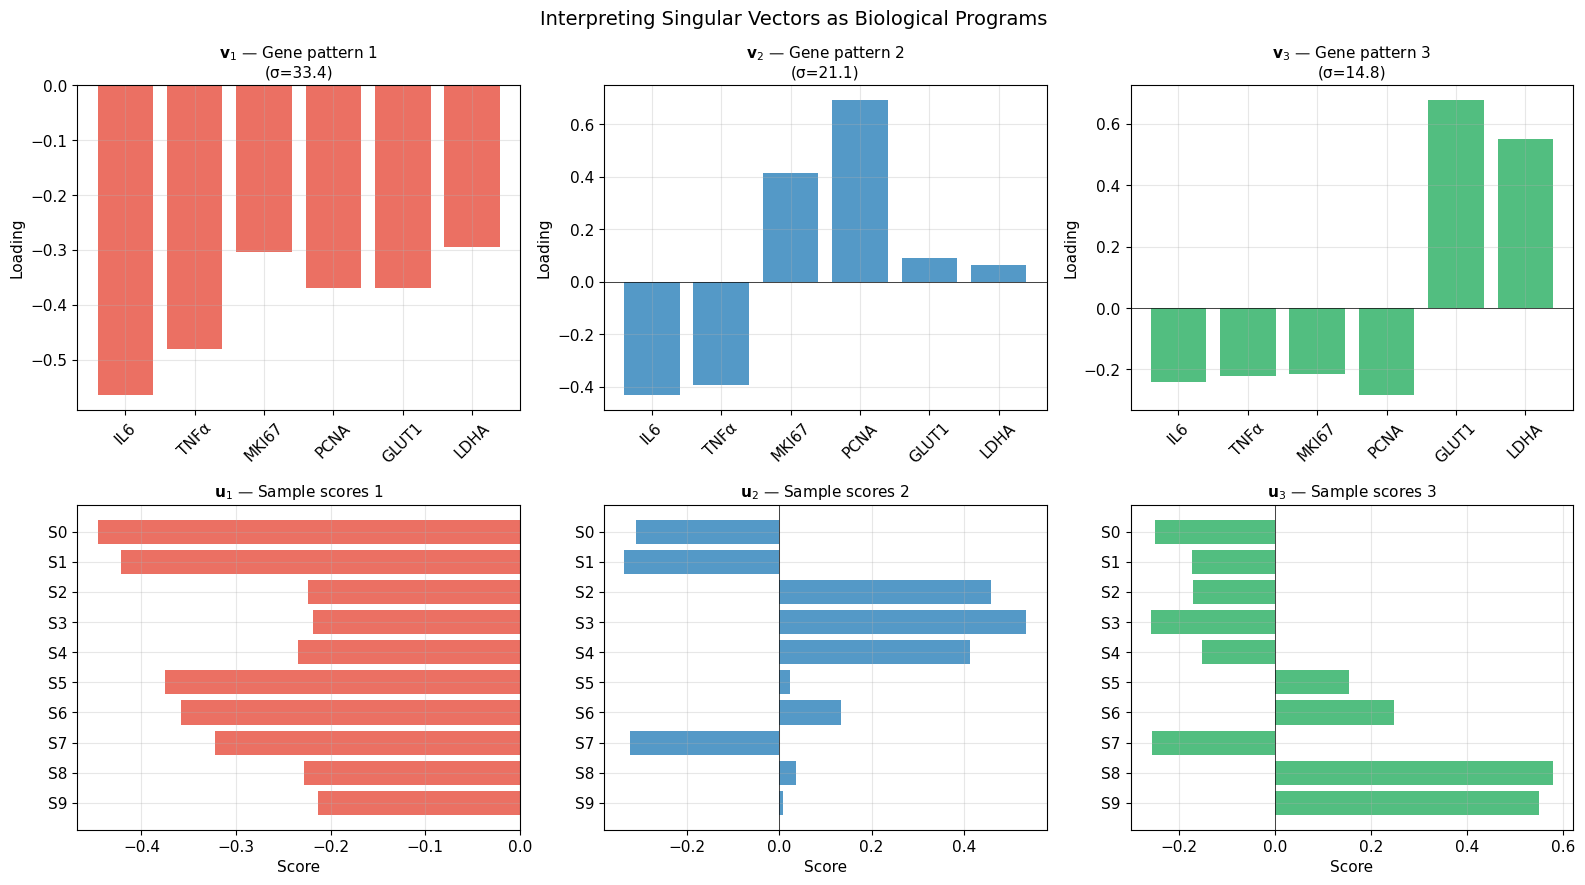

Top row: which genes load on each program (right singular vectors)
Bottom row: which samples score high on each program (left singular vectors)

The SVD automatically discovers these latent programs from the data!


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

program_labels = ['Immune\nresponse', 'Cell\nproliferation', 'Metabolic\nactivity']
colors = ['#e74c3c', '#2980b9', '#27ae60']

for k in range(3):
    # Top row: right singular vectors (gene loadings)
    ax = axes[0, k]
    bars = ax.bar(range(n), Vt[k, :], color=colors[k], alpha=0.8)
    ax.set_xticks(range(n))
    ax.set_xticklabels(gene_names, rotation=45)
    ax.set_ylabel('Loading')
    ax.set_title(f'$\mathbf{{v}}_{k+1}$ — Gene pattern {k+1}\n(σ={sigma[k]:.1f})', fontsize=11)
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(True, alpha=0.3)
    
    # Bottom row: left singular vectors (sample scores)
    ax = axes[1, k]
    bars = ax.barh(range(m), U[:, k], color=colors[k], alpha=0.8)
    ax.set_yticks(range(m))
    ax.set_yticklabels(sample_names)
    ax.set_xlabel('Score')
    ax.set_title(f'$\mathbf{{u}}_{k+1}$ — Sample scores {k+1}', fontsize=11)
    ax.axvline(0, color='black', lw=0.5)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()

plt.suptitle('Interpreting Singular Vectors as Biological Programs', fontsize=14)
plt.tight_layout()
plt.show()

print("Top row: which genes load on each program (right singular vectors)")
print("Bottom row: which samples score high on each program (left singular vectors)")
print("\nThe SVD automatically discovers these latent programs from the data!")

In [18]:
Vt

array([[-0.5635454 , -0.480584  , -0.30331311, -0.36913152, -0.36920749,
        -0.29476179],
       [-0.43241521, -0.39142341,  0.41214665,  0.69134821,  0.0898935 ,
         0.06242391],
       [-0.24005708, -0.22249668, -0.21659884, -0.28501988,  0.67795235,
         0.5523559 ],
       [ 0.48068917, -0.50455101, -0.36482797,  0.24069445, -0.36558618,
         0.4355223 ],
       [ 0.3781052 , -0.50578077,  0.62198132, -0.42167276,  0.11423812,
        -0.15330769],
       [-0.25254831,  0.23650802,  0.41383696, -0.26230041, -0.49928147,
         0.62525097]])

---
## 7. Truncated SVD (Section 7.5.5)

The **truncated SVD** keeps only the first $K$ singular values and vectors:

$$\hat{\mathbf{A}}_K = \mathbf{U}_K \mathbf{S}_K \mathbf{V}_K^T = \sum_{i=1}^{K} \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

This is the **best rank-$K$ approximation** in the Frobenius norm sense (Eckart-Young theorem):

$$\hat{\mathbf{A}}_K = \arg\min_{\text{rank}(\mathbf{B}) \leq K} \|\mathbf{A} - \mathbf{B}\|_F$$

The approximation error is:

$$\|\mathbf{A} - \hat{\mathbf{A}}_K\|_F = \sqrt{\sum_{i=K+1}^{r} \sigma_i^2}$$

If singular values drop off quickly (typical for structured data), a low-rank approximation is very accurate.

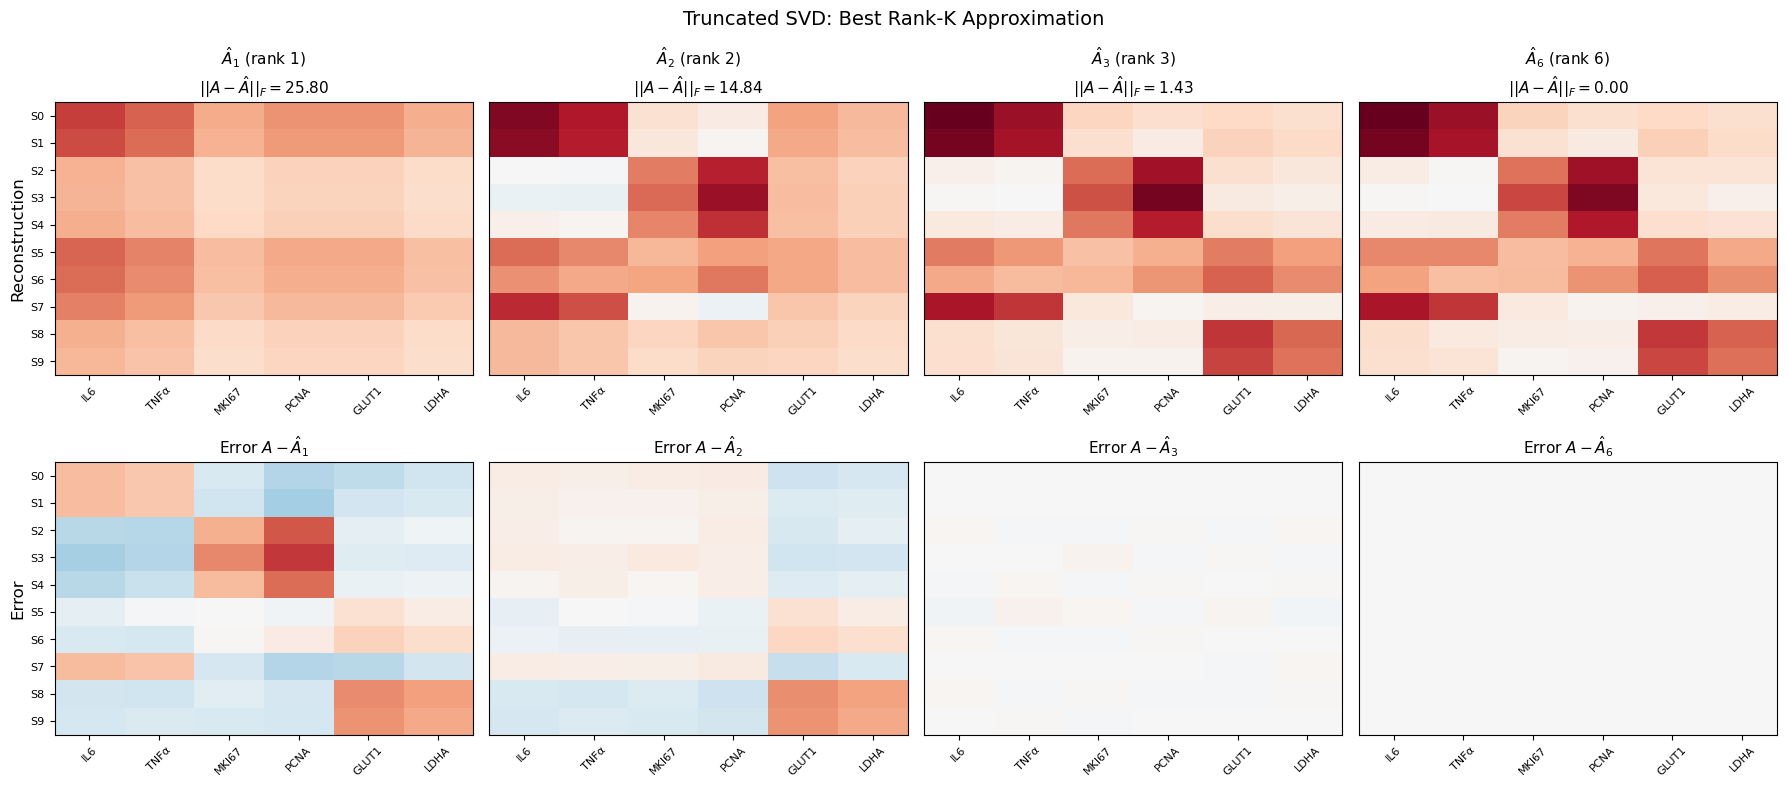

In [10]:
# Compute truncated SVD for different K values
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

vmax = np.max(np.abs(A))
K_values = [1, 2, 3, 6]

for col, K in enumerate(K_values):
    # Truncated reconstruction
    A_hat = U[:, :K] @ np.diag(sigma[:K]) @ Vt[:K, :]
    error = np.linalg.norm(A - A_hat, 'fro')
    theoretical_error = np.sqrt(np.sum(sigma[K:]**2))
    
    # Top: reconstruction
    ax = axes[0, col]
    ax.imshow(A_hat, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(f'$\\hat{{A}}_{K}$ (rank {K})\n$||A-\\hat{{A}}||_F = {error:.2f}$', fontsize=11)
    ax.set_xticks(range(n))
    ax.set_xticklabels(gene_names, rotation=45, fontsize=8)
    if col == 0:
        ax.set_yticks(range(m))
        ax.set_yticklabels(sample_names, fontsize=8)
    else:
        ax.set_yticks([])
    
    # Bottom: error matrix
    ax = axes[1, col]
    err_mat = A - A_hat
    ax.imshow(err_mat, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Error $A - \\hat{{A}}_{K}$', fontsize=11)
    ax.set_xticks(range(n))
    ax.set_xticklabels(gene_names, rotation=45, fontsize=8)
    if col == 0:
        ax.set_yticks(range(m))
        ax.set_yticklabels(sample_names, fontsize=8)
    else:
        ax.set_yticks([])

axes[0, 0].set_ylabel('Reconstruction', fontsize=12)
axes[1, 0].set_ylabel('Error', fontsize=12)
plt.suptitle('Truncated SVD: Best Rank-K Approximation', fontsize=14)
plt.tight_layout()
plt.show()

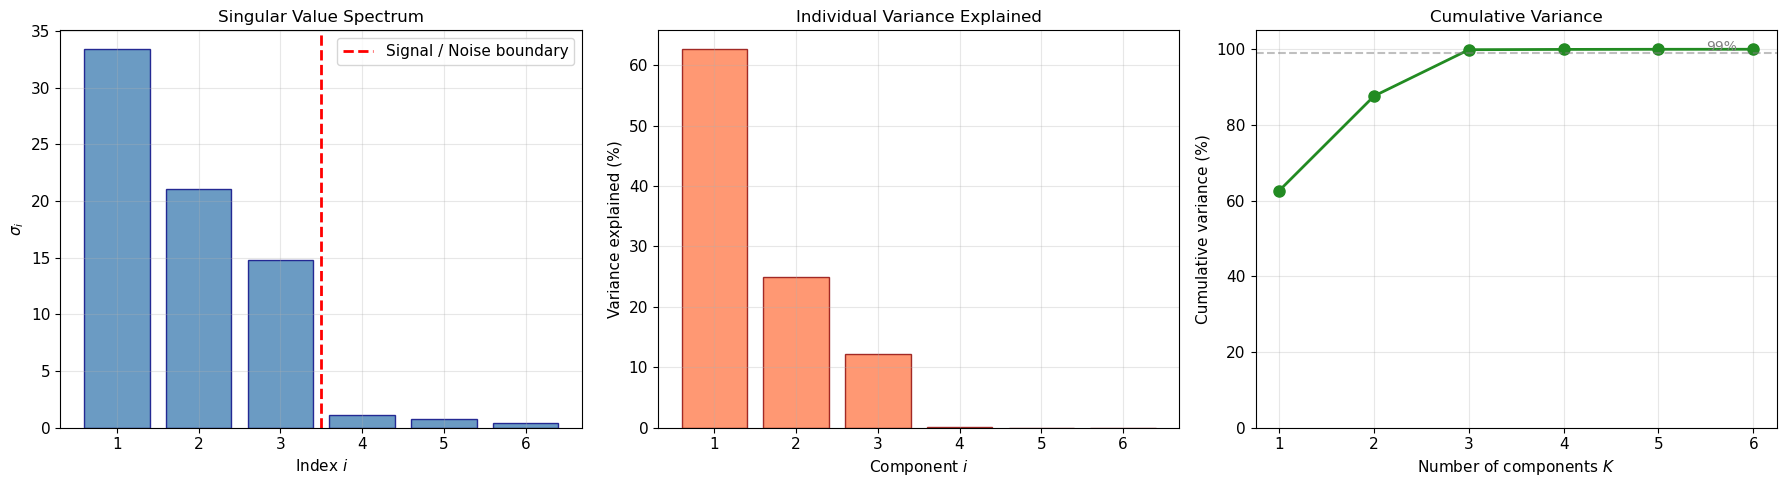

Variance explained by each component:
  σ_1 = 33.41  →  62.6%  (cumul: 62.6%)
  σ_2 = 21.10  →  25.0%  (cumul: 87.6%)
  σ_3 = 14.77  →  12.3%  (cumul: 99.9%)
  σ_4 = 1.16  →  0.1%  (cumul: 100.0%)
  σ_5 = 0.73  →  0.0%  (cumul: 100.0%)
  σ_6 = 0.43  →  0.0%  (cumul: 100.0%)

First 3 components explain 99.9% of variance — the 3 biological programs.
Remaining 0.1% is noise.


In [11]:
# Singular value spectrum and explained variance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Singular values
ax = axes[0]
ax.bar(range(1, n+1), sigma, color='steelblue', alpha=0.8, edgecolor='navy')
ax.set_xlabel('Index $i$')
ax.set_ylabel('$\sigma_i$')
ax.set_title('Singular Value Spectrum', fontsize=12)
ax.axhline(y=0, color='black', lw=0.5)
ax.grid(True, alpha=0.3)
# Mark the gap between signal and noise
ax.axvline(x=3.5, color='red', ls='--', lw=2, label='Signal / Noise boundary')
ax.legend()

# Explained variance (σ² / sum(σ²))
variance_explained = sigma**2 / np.sum(sigma**2)
cumulative_var = np.cumsum(variance_explained)

ax = axes[1]
ax.bar(range(1, n+1), variance_explained * 100, color='coral', alpha=0.8, edgecolor='darkred')
ax.set_xlabel('Component $i$')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Individual Variance Explained', fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(range(1, n+1), cumulative_var * 100, 'o-', color='forestgreen', lw=2, markersize=8)
ax.axhline(y=99, color='gray', ls='--', alpha=0.5)
ax.text(n - 0.5, 99.5, '99%', color='gray', fontsize=10)
ax.set_xlabel('Number of components $K$')
ax.set_ylabel('Cumulative variance (%)')
ax.set_title('Cumulative Variance', fontsize=12)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Variance explained by each component:")
for i in range(n):
    print(f"  σ_{i+1} = {sigma[i]:.2f}  →  {variance_explained[i]*100:.1f}%  (cumul: {cumulative_var[i]*100:.1f}%)")
print(f"\nFirst 3 components explain {cumulative_var[2]*100:.1f}% of variance — the 3 biological programs.")
print(f"Remaining {(1-cumulative_var[2])*100:.1f}% is noise.")

---
## 8. Compression Ratio

From Eq. 7.200, a rank-$K$ approximation of an $N \times D$ matrix requires $K(N + D + 1)$ parameters instead of $ND$.

In [12]:
print(f"Original matrix: {m} × {n} = {m*n} numbers")
print()
for K in [1, 2, 3]:
    n_params = K * (m + n + 1)
    ratio = m * n / n_params
    error = np.sqrt(np.sum(sigma[K:]**2))
    rel_error = error / np.linalg.norm(A, 'fro') * 100
    print(f"  Rank-{K}: {n_params} numbers (= {K}×({m}+{n}+1))"
          f"  →  {ratio:.1f}× compression  |  error: {rel_error:.1f}%")

print("\n--- Scaling to a real genomics dataset ---")
N_real, D_real = 1000, 20000  # 1000 patients, 20000 genes
K_real = 50  # 50 biological programs
n_orig = N_real * D_real
n_trunc = K_real * (N_real + D_real + 1)
print(f"\n  Full matrix: {N_real}×{D_real} = {n_orig:,} numbers")
print(f"  Rank-{K_real} SVD: {K_real}×({N_real}+{D_real}+1) = {n_trunc:,} numbers")
print(f"  Compression: {n_orig/n_trunc:.0f}×")

Original matrix: 10 × 6 = 60 numbers

  Rank-1: 17 numbers (= 1×(10+6+1))  →  3.5× compression  |  error: 61.1%
  Rank-2: 34 numbers (= 2×(10+6+1))  →  1.8× compression  |  error: 35.2%
  Rank-3: 51 numbers (= 3×(10+6+1))  →  1.2× compression  |  error: 3.4%

--- Scaling to a real genomics dataset ---

  Full matrix: 1000×20000 = 20,000,000 numbers
  Rank-50 SVD: 50×(1000+20000+1) = 1,050,050 numbers
  Compression: 19×


---
## 12. Image Compression with Truncated SVD

A classic application from Section 7.5.5 (Figure 7.9): treat a grayscale image as a matrix and approximate it with a low-rank SVD.

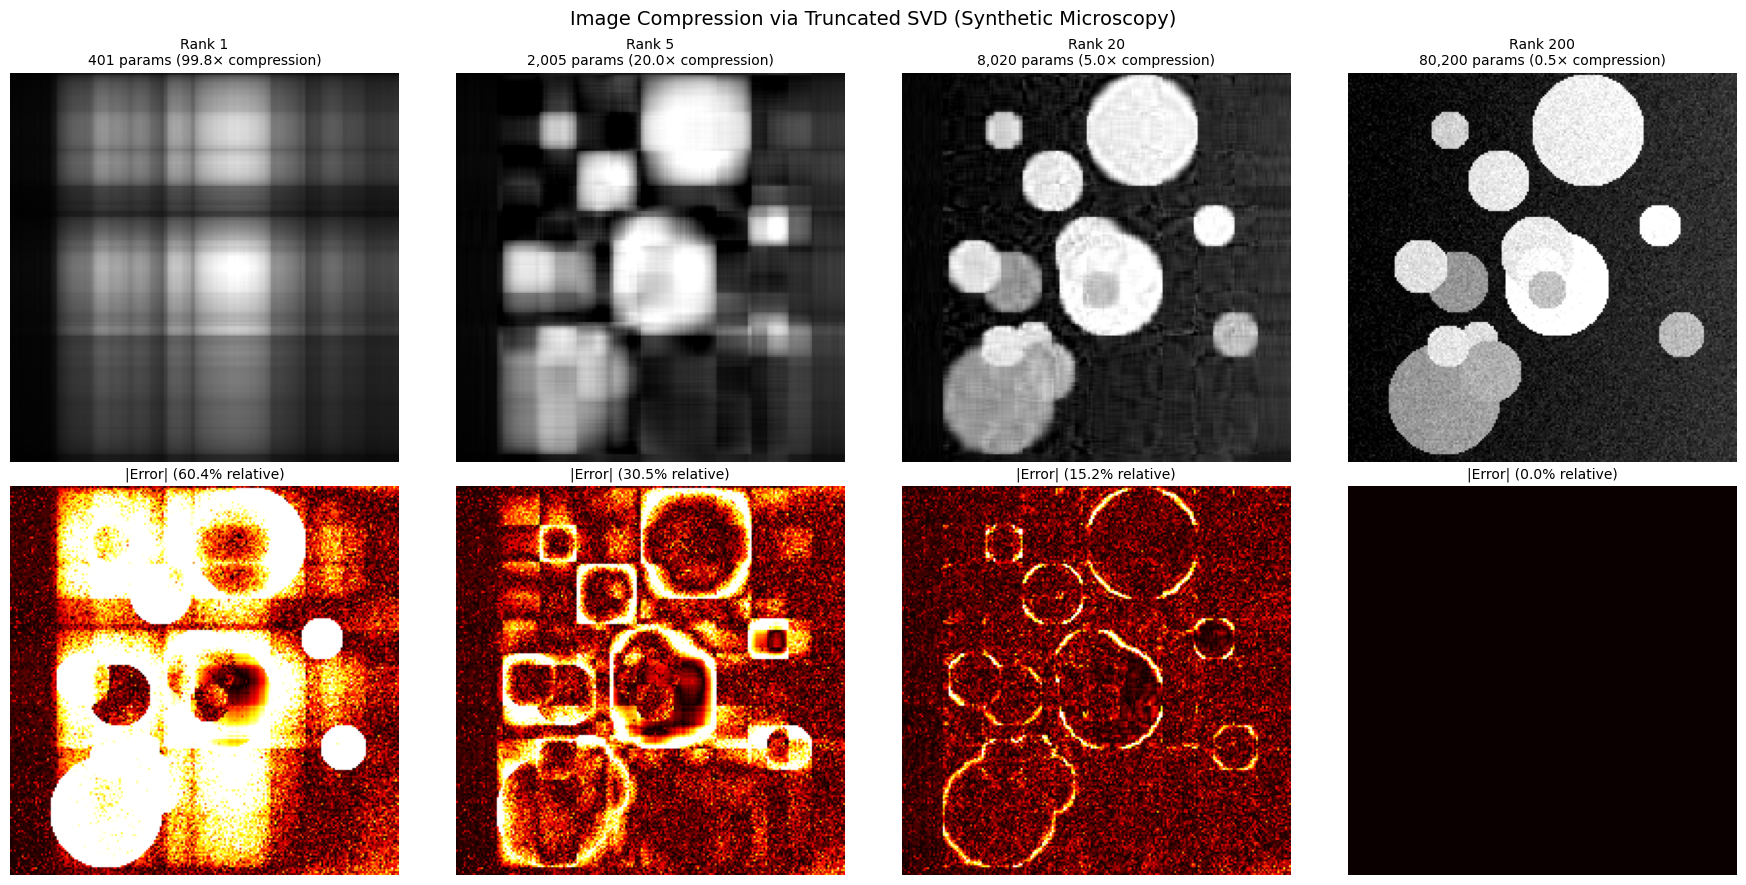

In [20]:
# Create a synthetic "microscopy" image (cell-like structures)
np.random.seed(0)
size = 200
image = np.zeros((size, size))

# Add circular "cells" with varying intensities
yy, xx = np.mgrid[:size, :size]
for _ in range(15):
    cx, cy = np.random.randint(20, size-20, 2)
    r = np.random.randint(10, 30)
    intensity = np.random.uniform(0.5, 1.0)
    mask = (xx - cx)**2 + (yy - cy)**2 < r**2
    image[mask] = intensity

# Add a gradient background
image += 0.2 * (xx / size)
# Add noise
image += 0.05 * np.random.randn(size, size)
image = np.clip(image, 0, 1)

# SVD of the image
U_img, sigma_img, Vt_img = np.linalg.svd(image, full_matrices=False)

# Reconstruct at different ranks
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

ranks = [1, 5, 20, 200]
for col, K in enumerate(ranks):
    reconstruction = U_img[:, :K] @ np.diag(sigma_img[:K]) @ Vt_img[:K, :]
    error = np.linalg.norm(image - reconstruction, 'fro') / np.linalg.norm(image, 'fro') * 100
    n_params = K * (size + size + 1)
    compression = (size * size) / n_params
    
    ax = axes[0, col]
    ax.imshow(reconstruction, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Rank {K}\n{n_params:,} params ({compression:.1f}× compression)', fontsize=10)
    ax.axis('off')
    
    ax = axes[1, col]
    ax.imshow(np.abs(image - reconstruction), cmap='hot', vmin=0, vmax=0.3)
    ax.set_title(f'|Error| ({error:.1f}% relative)', fontsize=10)
    ax.axis('off')

axes[0, 0].set_ylabel('Reconstruction', fontsize=12, rotation=0, labelpad=80)
axes[1, 0].set_ylabel('Error', fontsize=12, rotation=0, labelpad=50)
plt.suptitle('Image Compression via Truncated SVD (Synthetic Microscopy)', fontsize=14)
plt.tight_layout()
plt.show()

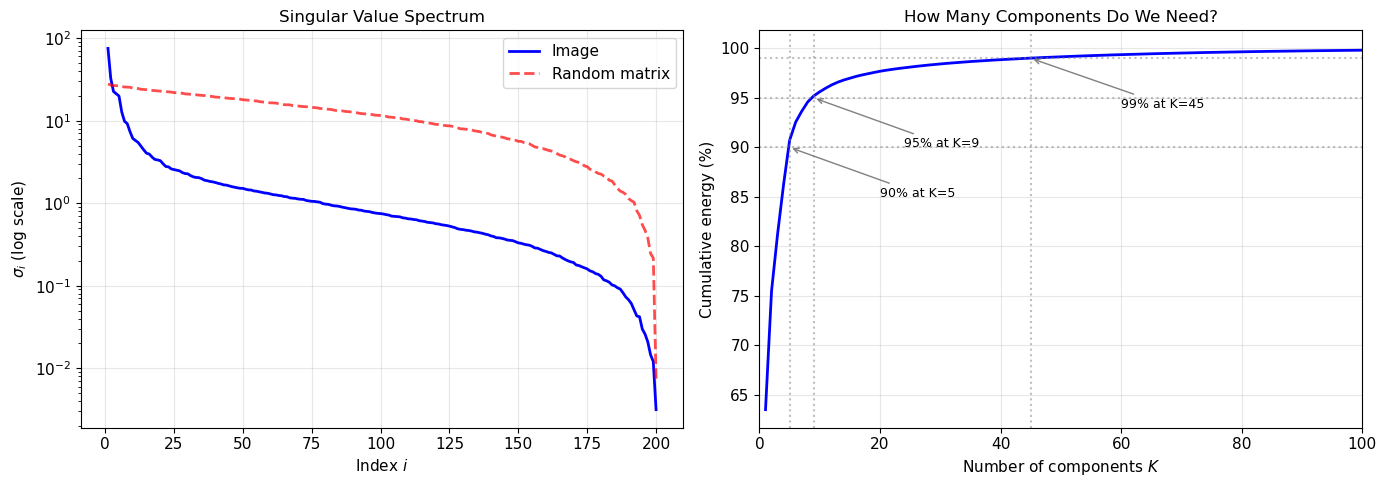

Natural images have rapidly decaying singular values (red line drops fast).
Random matrices have flat spectra (blue line stays high) — they are incompressible.
This is exactly the insight from Figure 7.10 in the book.


In [21]:
# Singular value spectrum of the image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(range(1, len(sigma_img)+1), sigma_img, 'b-', lw=2, label='Image')
# Compare with a random matrix of same size
random_matrix = np.random.randn(size, size)
_, sigma_rand, _ = np.linalg.svd(random_matrix)
ax.semilogy(range(1, len(sigma_rand)+1), sigma_rand, 'r--', lw=2, alpha=0.7, label='Random matrix')
ax.set_xlabel('Index $i$')
ax.set_ylabel('$\sigma_i$ (log scale)')
ax.set_title('Singular Value Spectrum', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
cum_energy = np.cumsum(sigma_img**2) / np.sum(sigma_img**2) * 100
ax.plot(range(1, len(cum_energy)+1), cum_energy, 'b-', lw=2)
for threshold in [90, 95, 99]:
    k_needed = np.searchsorted(cum_energy, threshold) + 1
    ax.axhline(y=threshold, color='gray', ls=':', alpha=0.5)
    ax.axvline(x=k_needed, color='gray', ls=':', alpha=0.5)
    ax.annotate(f'{threshold}% at K={k_needed}', xy=(k_needed, threshold),
               xytext=(k_needed+15, threshold-5), fontsize=9,
               arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Number of components $K$')
ax.set_ylabel('Cumulative energy (%)')
ax.set_title('How Many Components Do We Need?', fontsize=12)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Natural images have rapidly decaying singular values (red line drops fast).")
print("Random matrices have flat spectra (blue line stays high) — they are incompressible.")
print("This is exactly the insight from Figure 7.10 in the book.")

---
## Key Takeaways

1. **SVD exists for any matrix**: Unlike EVD, the SVD works for rectangular, non-symmetric, and even rank-deficient matrices

2. **Outer product form**: $\mathbf{A} = \sum \sigma_i \mathbf{u}_i \mathbf{v}_i^T$ decomposes a matrix into weighted rank-1 layers, ordered by importance ($\sigma_1 \geq \sigma_2 \geq \ldots$)

3. **Connection to EVD**: $\mathbf{V} = \text{evec}(\mathbf{A}^T\mathbf{A})$, $\mathbf{U} = \text{evec}(\mathbf{A}\mathbf{A}^T)$, eigenvalues $= \sigma_i^2$

4. **Truncated SVD**: The best rank-$K$ approximation in Frobenius norm; error $= \sqrt{\sum_{i>K} \sigma_i^2}$

5. **Pseudo inverse**: $\mathbf{A}^\dagger = \mathbf{V} \mathbf{S}^{-1} \mathbf{U}^T$ gives least-squares (overdetermined) or minimum-norm (underdetermined) solutions

6. **Fundamental subspaces**: Left singular vectors span the range, right singular vectors for zero $\sigma$ span the null space; rank + nullity $= n$

7. **Geometry**: SVD decomposes any linear map as rotate → scale → rotate, mapping the unit sphere to an ellipsoid with semi-axes $= \sigma_i$